# Threshold Optimization for Stress Detection

**Objective**: Find the optimal threshold for Logistic Regression that:
- Achieves **≥80% Recall** (catches most stress episodes)
- Maintains **≤20% False Alarm Rate** (acceptable false positives)

This is critical for a screening/monitoring system where:
- Missing stress is costly (we want high sensitivity)
- But we can tolerate some false alarms (but not too many)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


## 1. Load Predictions


In [2]:
# Load predictions
predictions_path = '../experiments/01_classical_ml/results/logistic_regression_predictions.csv'
df = pd.read_csv(predictions_path)

print(f"Total samples: {len(df)}")
print(f"Stress samples (y=1): {(df['y_true'] == 1).sum()}")
print(f"Non-stress samples (y=0): {(df['y_true'] == 0).sum()}")
print(f"\nClass distribution: {(df['y_true'] == 1).sum() / len(df) * 100:.1f}% stress")

df.head(10)


Total samples: 1430
Stress samples (y=1): 191
Non-stress samples (y=0): 1239

Class distribution: 13.4% stress


,subject_id,y_true,y_pred,y_proba
0,0a73ef1b-da67-43ff-b61a-f98c151be799,0,0,0.022717
1,0a73ef1b-da67-43ff-b61a-f98c151be799,0,0,0.057130
2,0a73ef1b-da67-43ff-b61a-f98c151be799,0,1,0.434559
3,0a73ef1b-da67-43ff-b61a-f98c151be799,0,1,0.664577
4,0a73ef1b-da67-43ff-b61a-f98c151be799,0,0,0.179357
5,0a73ef1b-da67-43ff-b61a-f98c151be799,0,0,0.115243
6,0a73ef1b-da67-43ff-b61a-f98c151be799,0,0,0.162979
7,0a73ef1b-da67-43ff-b61a-f98c151be799,0,1,0.720967
8,0a73ef1b-da67-43ff-b61a-f98c151be799,0,0,0.029788
9,0a73ef1b-da67-43ff-b61a-f98c151be799,0,0,0.008340


## 2. Define Helper Functions


In [3]:
def calculate_metrics(y_true, y_pred):
    """Calculate key metrics for threshold analysis."""
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    gmean = np.sqrt(sensitivity * specificity)
    
    return {
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'False Alarm Rate': far,
        'G-Mean': gmean
    }

print("✓ Helper functions defined")


✓ Helper functions defined


## 3. Threshold Sweep Analysis


In [4]:
# Extract labels and probabilities
y_true = df['y_true'].values
y_proba = df['y_proba'].values

# Test thresholds from 0.01 to 0.99
thresholds = np.arange(0.01, 1.00, 0.01)
results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    metrics = calculate_metrics(y_true, y_pred_thresh)
    metrics['Threshold'] = threshold
    results.append(metrics)

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(f"✓ Threshold sweep completed!")
print(f"  Tested {len(thresholds)} thresholds from {thresholds[0]:.2f} to {thresholds[-1]:.2f}")
results_df.head(10)


✓ Threshold sweep completed!
  Tested 99 thresholds from 0.01 to 0.99


,TP,TN,FP,FN,Sensitivity (Recall),Specificity,Precision,False Alarm Rate,G-Mean,Threshold
0,189,227,1012,2,0.989529,0.183212,0.157369,0.816788,0.425786,0.01
1,189,280,959,2,0.989529,0.225989,0.164634,0.774011,0.472887,0.02
2,188,323,916,3,0.984293,0.260694,0.170290,0.739306,0.506556,0.03
3,187,347,892,4,0.979058,0.280065,0.173309,0.719935,0.523640,0.04
4,186,377,862,5,0.973822,0.304278,0.177481,0.695722,0.544346,0.05
5,186,405,834,5,0.973822,0.326877,0.182353,0.673123,0.564198,0.06
6,186,431,808,5,0.973822,0.347861,0.187123,0.652139,0.582027,0.07
7,186,450,789,5,0.973822,0.363196,0.190769,0.636804,0.594717,0.08
8,186,466,773,5,0.973822,0.376110,0.193952,0.623890,0.605197,0.09
9,186,483,756,5,0.973822,0.389831,0.197452,0.610169,0.616138,0.10


## 4. Find Optimal Threshold (80% Recall, ≤20% FAR)


In [9]:
# Set constraints
target_recall = 0.70
max_far = 0.35

# Filter thresholds meeting both constraints
meets_recall = results_df['Sensitivity (Recall)'] >= target_recall
meets_far = results_df['False Alarm Rate'] <= max_far
feasible = results_df[meets_recall & meets_far].copy()

print("="*70)
print("CONSTRAINT-BASED THRESHOLD OPTIMIZATION")
print("="*70)
print(f"Target: Recall ≥ {target_recall*100:.0f}% AND FAR ≤ {max_far*100:.0f}%")
print(f"\nFeasible thresholds found: {len(feasible)}")

if len(feasible) > 0:
    # Pick threshold with best G-Mean among feasible options
    best_idx = feasible['G-Mean'].idxmax()
    best_threshold = feasible.loc[best_idx]
    
    print("\n" + "="*70)
    print(f"🎯 OPTIMAL THRESHOLD: {best_threshold['Threshold']:.4f}")
    print("="*70)
    print(f"Recall (Sensitivity):    {best_threshold['Sensitivity (Recall)']*100:.2f}%")
    print(f"False Alarm Rate:        {best_threshold['False Alarm Rate']*100:.2f}%")
    print(f"Specificity:             {best_threshold['Specificity']*100:.2f}%")
    print(f"Precision:               {best_threshold['Precision']*100:.2f}%")
    print(f"G-Mean:                  {best_threshold['G-Mean']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {best_threshold['TP']:.0f}  |  FN: {best_threshold['FN']:.0f}")
    print(f"  FP: {best_threshold['FP']:.0f}  |  TN: {best_threshold['TN']:.0f}")
    print("="*70)
    
    print(f"\nFeasible threshold range: [{feasible['Threshold'].min():.3f}, {feasible['Threshold'].max():.3f}]")
    
else:
    print("\n⚠️  WARNING: No threshold satisfies BOTH constraints!")
    print("\nWhat's achievable:")
    
    within_far = results_df[meets_far]
    if len(within_far) > 0:
        best_recall = within_far['Sensitivity (Recall)'].max()
        best_recall_row = within_far.loc[within_far['Sensitivity (Recall)'].idxmax()]
        print(f"  Best recall with FAR ≤ 20%: {best_recall*100:.1f}% (threshold={best_recall_row['Threshold']:.3f})")
    
    within_recall = results_df[meets_recall]
    if len(within_recall) > 0:
        best_far = within_recall['False Alarm Rate'].min()
        best_far_row = within_recall.loc[within_recall['False Alarm Rate'].idxmin()]
        print(f"  Lowest FAR with recall ≥ 80%: {best_far*100:.1f}% (threshold={best_far_row['Threshold']:.3f})")


CONSTRAINT-BASED THRESHOLD OPTIMIZATION
Target: Recall ≥ 70% AND FAR ≤ 35%

Feasible thresholds found: 19

🎯 OPTIMAL THRESHOLD: 0.5400
Recall (Sensitivity):    72.25%
False Alarm Rate:        22.03%
Specificity:             77.97%
Precision:               33.58%
G-Mean:                  0.7505

Confusion Matrix:
  TP: 138  |  FN: 53
  FP: 273  |  TN: 966

Feasible threshold range: [0.370, 0.550]


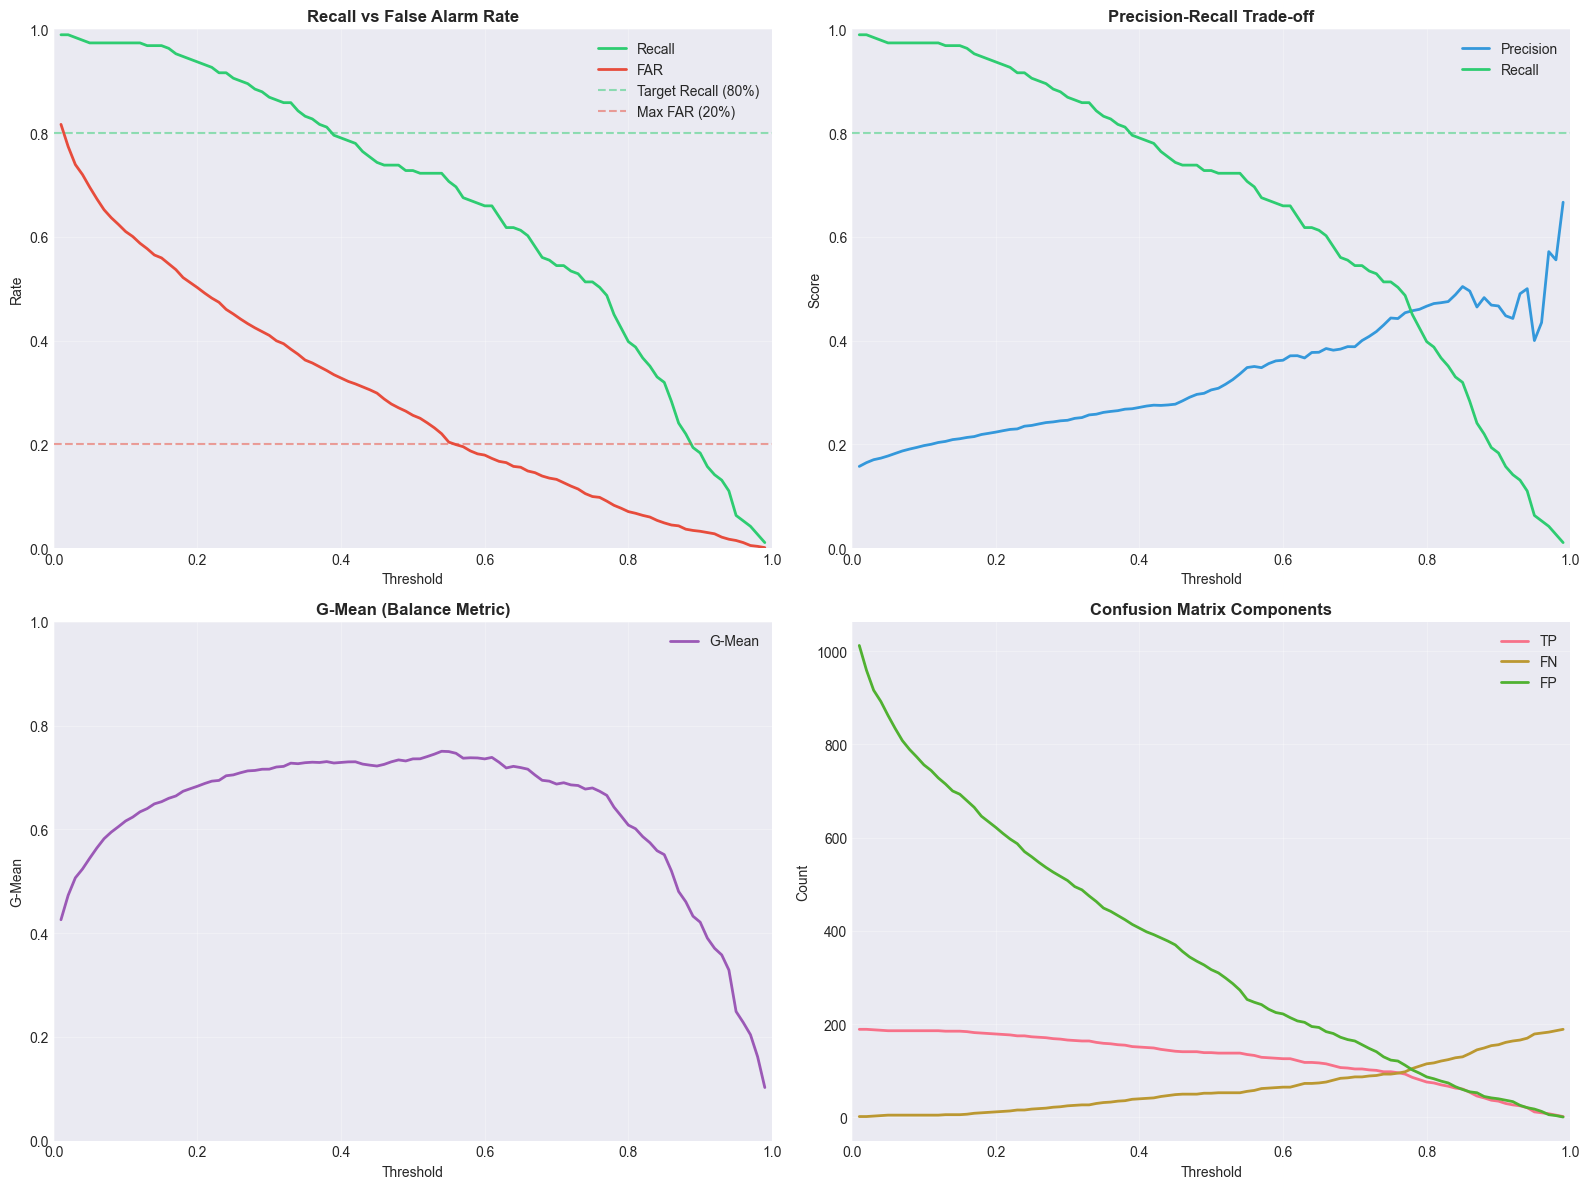


✓ Saved: threshold_optimization.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Recall vs FAR
ax = axes[0, 0]
ax.plot(results_df['Threshold'], results_df['Sensitivity (Recall)'], label='Recall', lw=2, color='#2ecc71')
ax.plot(results_df['Threshold'], results_df['False Alarm Rate'], label='FAR', lw=2, color='#e74c3c')
ax.axhline(0.80, color='#2ecc71', ls='--', alpha=0.5, label='Target Recall (80%)')
ax.axhline(0.20, color='#e74c3c', ls='--', alpha=0.5, label='Max FAR (20%)')
if len(feasible) > 0:
    ax.axvline(best_threshold['Threshold'], color='black', ls=':', lw=2, label=f"Optimal: {best_threshold['Threshold']:.3f}")
ax.set_xlabel('Threshold'); ax.set_ylabel('Rate')
ax.set_title('Recall vs False Alarm Rate', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1])

# Plot 2: Precision vs Recall
ax = axes[0, 1]
ax.plot(results_df['Threshold'], results_df['Precision'], label='Precision', lw=2, color='#3498db')
ax.plot(results_df['Threshold'], results_df['Sensitivity (Recall)'], label='Recall', lw=2, color='#2ecc71')
ax.axhline(0.80, color='#2ecc71', ls='--', alpha=0.5)
if len(feasible) > 0:
    ax.axvline(best_threshold['Threshold'], color='black', ls=':', lw=2)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision-Recall Trade-off', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1])

# Plot 3: G-Mean
ax = axes[1, 0]
ax.plot(results_df['Threshold'], results_df['G-Mean'], lw=2, color='#9b59b6', label='G-Mean')
if len(feasible) > 0:
    feasible_gmean = results_df.loc[meets_recall & meets_far, 'G-Mean']
    feasible_thresh = results_df.loc[meets_recall & meets_far, 'Threshold']
    ax.fill_between(feasible_thresh, 0, feasible_gmean, alpha=0.3, color='green', label='Feasible')
    ax.axvline(best_threshold['Threshold'], color='black', ls=':', lw=2)
    ax.scatter([best_threshold['Threshold']], [best_threshold['G-Mean']], s=200, color='red', zorder=5, marker='*', edgecolors='black', lw=2)
ax.set_xlabel('Threshold'); ax.set_ylabel('G-Mean')
ax.set_title('G-Mean (Balance Metric)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1])

# Plot 4: Confusion Matrix Components
ax = axes[1, 1]
ax.plot(results_df['Threshold'], results_df['TP'], label='TP', lw=2)
ax.plot(results_df['Threshold'], results_df['FN'], label='FN', lw=2)
ax.plot(results_df['Threshold'], results_df['FP'], label='FP', lw=2)
if len(feasible) > 0:
    ax.axvline(best_threshold['Threshold'], color='black', ls=':', lw=2)
ax.set_xlabel('Threshold'); ax.set_ylabel('Count')
ax.set_title('Confusion Matrix Components', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim([0,1])

plt.tight_layout()
plt.savefig('../experiments/01_classical_ml/results/figures/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: threshold_optimization.png")


In [7]:
import json

if len(feasible) > 0:
    # Save optimal threshold configuration
    optimal_config = {
        'threshold': float(best_threshold['Threshold']),
        'target_recall': target_recall,
        'max_far': max_far,
        'achieved_recall': float(best_threshold['Sensitivity (Recall)']),
        'achieved_far': float(best_threshold['False Alarm Rate']),
        'precision': float(best_threshold['Precision']),
        'specificity': float(best_threshold['Specificity']),
        'gmean': float(best_threshold['G-Mean']),
        'confusion_matrix': {
            'TP': int(best_threshold['TP']),
            'TN': int(best_threshold['TN']),
            'FP': int(best_threshold['FP']),
            'FN': int(best_threshold['FN'])
        },
        'validation_samples': len(df),
        'stress_samples': int((df['y_true']==1).sum()),
        'notes': 'Optimized for 80% recall with maximum 20% false alarm rate'
    }
    
    with open('../experiments/01_classical_ml/results/optimal_threshold_config.json', 'w') as f:
        json.dump(optimal_config, f, indent=2)
    
    print("="*70)
    print("✓ OPTIMAL THRESHOLD CONFIGURATION SAVED")
    print("="*70)
    print(json.dumps(optimal_config, indent=2))
    
    # Practical interpretation
    print("\n" + "="*70)
    print("📊 PRACTICAL INTERPRETATION")
    print("="*70)
    print(f"Out of 100 stress episodes:")
    print(f"  ✓ You will catch: {best_threshold['Sensitivity (Recall)']*100:.0f}")
    print(f"  ✗ You will miss: {(1-best_threshold['Sensitivity (Recall)'])*100:.0f}")
    print(f"\nOut of 100 non-stress periods:")
    print(f"  ✓ Correctly identified: {(1-best_threshold['False Alarm Rate'])*100:.0f}")
    print(f"  ✗ False alarms: {best_threshold['False Alarm Rate']*100:.0f}")
    print(f"\nWhen system alerts 'stress':")
    print(f"  ✓ It's correct {best_threshold['Precision']*100:.0f}% of the time")
    print("="*70)
    
else:
    print("⚠️  No optimal threshold found - constraints cannot be satisfied")
    print("Consider relaxing constraints or improving the model")


⚠️  No optimal threshold found - constraints cannot be satisfied
Consider relaxing constraints or improving the model
